# **PROYECTO FINAL COMUNICACIONES DIGITALES 2026-1**

## **Módem Óptico Espacio-Temporal Half-Duplex**

#### *Simón Llano, Abdy Sánchez*

# **CONTEXTO**

El proyecto consiste en diseñar e implementar un **módem óptico espacio-temporal half-duplex** que permita transmitir información entre dos computadores sin usar una conexión de red. La idea principal es que el transmisor convierta un archivo de texto en una secuencia de cuadros visuales mostrados en pantalla, mientras que el receptor capture esos cuadros con una cámara web, corrija las distorsiones del canal óptico y reconstruya el mensaje original.

El objetivo final es lograr la transmisión de un texto de **500 caracteres** desde la pantalla de un computador hacia la cámara de otro, a una distancia mínima de **50 cm**, en un tiempo máximo de **10 segundos**, manteniendo una baja tasa de error. Para ello, el sistema debe integrar técnicas propias de comunicaciones digitales, como modulación, sincronización, detección, calibración, corrección geométrica y codificación de canal, adaptadas al entorno práctico pantalla–cámara.


# **LIBRERÍAS**

In [34]:
#pip install numpy scipy matplotlib pillow tqdm opencv-contrib-python
#pip install notebook ipykernel

In [35]:
# ============================================================
# 1. Librerías estándar de Python
# ============================================================

import os
import sys
import time
import math
from pathlib import Path
from dataclasses import dataclass


# ============================================================
# 2. Librerías numéricas y de procesamiento de señales
# ============================================================

import numpy as np
from scipy import signal
from scipy import ndimage


# ============================================================
# 3. Librerías de imagen y visualización
# ============================================================

import cv2
from PIL import Image
import matplotlib.pyplot as plt


# ============================================================
# 4. Utilidades opcionales
# ============================================================

from tqdm import tqdm

# **FASE A: Transmisor y codificación espacial**

**Objetivo:** crear la cadena de transmisión capaz de convertir texto en cuadros visuales codificados, y
verificar el lazo digital de extremo a extremo en simulación antes de pasar al canal real.

## Inicialización & Prueba Patrón BPSK

Entorno inicializado correctamente.
Python: 3.13.2
NumPy: 2.2.6
SciPy signal disponible: True
OpenCV: 4.13.0
Pillow: 12.0.0
Directorio de salida: c:\Users\Dell\Documents\de la U\2026-1\COMUNICACIONES DIGITALES\Proyecto Final\outputs\fase1
Imagen de prueba guardada en: c:\Users\Dell\Documents\de la U\2026-1\COMUNICACIONES DIGITALES\Proyecto Final\outputs\fase1\frames\test_bpsk_gray_pattern.png


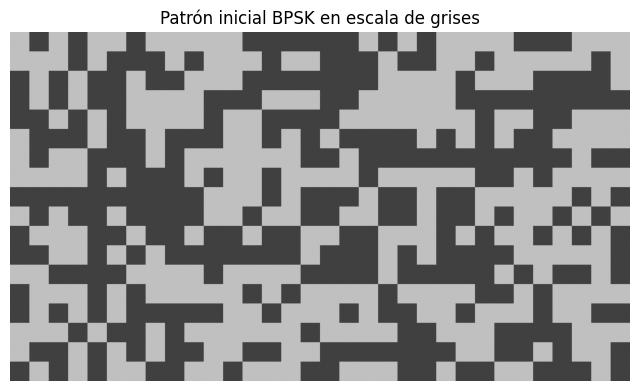

In [36]:
"""
Fase 1 — Diseño del formato visual
Módem óptico espacio-temporal

Objetivo de este archivo:
- Inicializar librerías base.
- Verificar OpenCV, NumPy y SciPy.
- Crear carpetas de salida.
- Dejar constantes iniciales para BPSK en escala de grises con Manchester.
"""

# ============================================================
# Configuración general del proyecto
# ============================================================

PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "fase1"
FRAME_DIR = OUTPUT_DIR / "frames"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FRAME_DIR.mkdir(parents=True, exist_ok=True)

np.set_printoptions(precision=3, suppress=True)


# ============================================================
# Constantes iniciales del sistema visual
# ============================================================

@dataclass
class VisualConfig:
    """
    Configuración inicial para generar frames visuales.

    Nota:
    Estos valores son iniciales. Luego los ajustaremos según cámara,
    pantalla, distancia, brillo ambiente y tamaño de celda.
    """

    # Tamaño del frame generado en pixeles
    frame_width: int = 1280
    frame_height: int = 720

    # Tamaño de cada macropixel/celda visual
    cell_size: int = 40

    # Niveles de gris para BPSK visual
    # Evitamos 0 y 255 al inicio para reducir clipping/saturación.
    gray_low: int = 64
    gray_high: int = 192

    # Fondo oscuro para mejorar contraste con la grilla
    background_gray: int = 20

    # Duración inicial de símbolo en segundos
    # El enunciado sugiere iniciar alrededor de 100 ms.
    symbol_duration_s: float = 0.100

    # Semilla para reproducibilidad
    random_seed: int = 42


cfg = VisualConfig()
rng = np.random.default_rng(cfg.random_seed)


# ============================================================
# Funciones auxiliares básicas
# ============================================================

def check_environment() -> None:
    """
    Imprime versiones principales para verificar instalación.
    """
    print("Entorno inicializado correctamente.")
    print(f"Python: {sys.version.split()[0]}")
    print(f"NumPy: {np.__version__}")
    print(f"SciPy signal disponible: {signal is not None}")
    print(f"OpenCV: {cv2.__version__}")
    print(f"Pillow: {Image.__version__}")
    print(f"Directorio de salida: {OUTPUT_DIR}")


def show_gray_image(img: np.ndarray, title: str = "Imagen en escala de grises") -> None:
    """
    Muestra una imagen en escala de grises usando matplotlib.

    Parámetros:
        img: arreglo NumPy 2D con valores uint8 entre 0 y 255.
        title: título de la figura.
    """
    plt.figure(figsize=(8, 5))
    plt.imshow(img, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()


def save_gray_image(img: np.ndarray, filename: str) -> Path:
    """
    Guarda una imagen en escala de grises usando OpenCV.

    Parámetros:
        img: imagen 2D uint8.
        filename: nombre del archivo, por ejemplo 'test.png'.

    Retorna:
        Ruta completa del archivo guardado.
    """
    path = FRAME_DIR / filename

    if img.dtype != np.uint8:
        raise ValueError("La imagen debe estar en formato uint8.")

    ok = cv2.imwrite(str(path), img)

    if not ok:
        raise IOError(f"No se pudo guardar la imagen en: {path}")

    return path


def create_test_bpsk_pattern(config: VisualConfig) -> np.ndarray:
    """
    Crea un patrón visual simple con niveles BPSK en escala de grises.

    No es todavía el modulador final.
    Solo sirve para comprobar que podemos crear y guardar frames.
    """

    h, w = config.frame_height, config.frame_width
    img = np.full((h, w), config.background_gray, dtype=np.uint8)

    rows = h // config.cell_size
    cols = w // config.cell_size

    bits = rng.integers(0, 2, size=(rows, cols), dtype=np.uint8)

    for r in range(rows):
        for c in range(cols):
            y0 = r * config.cell_size
            y1 = y0 + config.cell_size
            x0 = c * config.cell_size
            x1 = x0 + config.cell_size

            img[y0:y1, x0:x1] = (
                config.gray_high if bits[r, c] == 1 else config.gray_low
            )

    return img


# ============================================================
# Prueba rápida de funcionamiento
# ============================================================

if __name__ == "__main__":
    check_environment()

    test_img = create_test_bpsk_pattern(cfg)
    saved_path = save_gray_image(test_img, "test_bpsk_gray_pattern.png")

    print(f"Imagen de prueba guardada en: {saved_path}")

    show_gray_image(test_img, "Patrón inicial BPSK en escala de grises")

## Módulo: De texto a Bits & Despliegue

```
texto
→ bytes UTF-8
→ bits
→ paquetes con preámbulo, índice de frame, total de frames, longitud y CRC16
→ codificación Manchester
→ símbolos BPSK visuales
→ niveles de gris
→ grilla con fiduciales y pilotos
→ visualización en pantalla

bit 0 → [1, 0]  transición alto-bajo
bit 1 → [0, 1]  transición bajo-alto

símbolo 0 → gris bajo  = 64
símbolo 1 → gris alto  = 192
```

In [37]:
from __future__ import annotations

import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable, List, Tuple

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

np.set_printoptions(precision=3, suppress=True)

In [38]:
@dataclass
class TxVisualConfig:
    # Tamaño del frame generado
    frame_width: int = 1280
    frame_height: int = 720

    # Grilla visual
    grid_cols: int = 48
    grid_rows: int = 26
    cell_size: int = 24

    # BPSK visual en escala de grises
    # Evitamos 0 y 255 para datos, para reducir clipping/saturación en cámara.
    gray_low: int = 64
    gray_high: int = 192

    # Fondo y zonas silenciosas
    background_gray: int = 16
    quiet_gray: int = 16

    # Marcadores fiduciales tipo finder
    fiducial_low: int = 0
    fiducial_high: int = 255
    marker_size_cells: int = 7

    # Duración inicial por frame
    frame_duration_s: float = 0.20

    # Carpeta de salida
    output_dir: Path = Path("outputs/fase1/frames")

    # Útil para depuración, pero apagar para transmisión real
    debug_text: bool = False


DATA = "DATA"
FIDUCIAL = "FIDUCIAL"
QUIET = "QUIET"
PILOT_LOW = "PILOT_LOW"
PILOT_HIGH = "PILOT_HIGH"

# Preámbulo fijo de 32 bits. Luego servirá para sincronización en recepción.
PREAMBLE_BITS = np.array(
    [int(b) for b in "10111000110100101110001001011010"],
    dtype=np.uint8,
)

cfg = TxVisualConfig()
cfg.output_dir.mkdir(parents=True, exist_ok=True)

print(cfg)

TxVisualConfig(frame_width=1280, frame_height=720, grid_cols=48, grid_rows=26, cell_size=24, gray_low=64, gray_high=192, background_gray=16, quiet_gray=16, fiducial_low=0, fiducial_high=255, marker_size_cells=7, frame_duration_s=0.2, output_dir=WindowsPath('outputs/fase1/frames'), debug_text=False)


In [39]:
def bytes_to_bits(data: bytes) -> np.ndarray:
    """Convierte bytes a bits MSB-first."""
    if not data:
        return np.array([], dtype=np.uint8)
    return np.unpackbits(np.frombuffer(data, dtype=np.uint8)).astype(np.uint8)


def bits_to_bytes(bits: np.ndarray) -> bytes:
    """Convierte bits MSB-first a bytes. Rellena con ceros si hace falta."""
    bits = np.asarray(bits, dtype=np.uint8)

    if bits.size == 0:
        return b""

    pad = (-bits.size) % 8
    if pad:
        bits = np.concatenate([bits, np.zeros(pad, dtype=np.uint8)])

    return np.packbits(bits).tobytes()


def int_to_bits(value: int, nbits: int) -> np.ndarray:
    """Convierte un entero no negativo a nbits MSB-first."""
    if value < 0:
        raise ValueError("value debe ser no negativo.")
    if value >= (1 << nbits):
        raise ValueError(f"value={value} no cabe en {nbits} bits.")

    return np.array(
        [(value >> shift) & 1 for shift in range(nbits - 1, -1, -1)],
        dtype=np.uint8,
    )


def manchester_encode(bits: np.ndarray) -> np.ndarray:
    """
    Codificación Manchester.

    Convención:
        bit 0 -> [1, 0]  transición alto-bajo
        bit 1 -> [0, 1]  transición bajo-alto

    Cada bit original produce dos símbolos visuales BPSK.
    """
    bits = np.asarray(bits, dtype=np.uint8)

    if not np.all((bits == 0) | (bits == 1)):
        raise ValueError("Manchester solo acepta bits 0/1.")

    encoded = np.empty(bits.size * 2, dtype=np.uint8)
    encoded[0::2] = 1 - bits
    encoded[1::2] = bits
    return encoded


def crc16_ccitt(data: bytes, init: int = 0xFFFF) -> int:
    """CRC-16/CCITT-FALSE: poly=0x1021, init=0xFFFF."""
    crc = init

    for byte in data:
        crc ^= byte << 8
        for _ in range(8):
            if crc & 0x8000:
                crc = ((crc << 1) ^ 0x1021) & 0xFFFF
            else:
                crc = (crc << 1) & 0xFFFF

    return crc & 0xFFFF

In [40]:
def marker_origins(cfg: TxVisualConfig) -> List[Tuple[int, int]]:
    """Esquinas superiores izquierdas de los cuatro marcadores."""
    m = cfg.marker_size_cells
    return [
        (0, 0),
        (0, cfg.grid_cols - m),
        (cfg.grid_rows - m, 0),
        (cfg.grid_rows - m, cfg.grid_cols - m),
    ]


def build_role_grid(cfg: TxVisualConfig) -> np.ndarray:
    """
    Roles de la grilla:
    - DATA: símbolos Manchester/BPSK.
    - FIDUCIAL: marcadores tipo finder.
    - QUIET: zona de guarda alrededor de marcadores.
    - PILOT_HIGH / PILOT_LOW: pilotos de brillo conocidos.
    """
    roles = np.full((cfg.grid_rows, cfg.grid_cols), DATA, dtype=object)
    m = cfg.marker_size_cells

    # Marcadores
    for r0, c0 in marker_origins(cfg):
        roles[r0:r0 + m, c0:c0 + m] = FIDUCIAL

    # Zona silenciosa de 1 celda alrededor de cada marcador
    for r0, c0 in marker_origins(cfg):
        r_start = max(0, r0 - 1)
        r_end = min(cfg.grid_rows, r0 + m + 1)
        c_start = max(0, c0 - 1)
        c_end = min(cfg.grid_cols, c0 + m + 1)

        region = roles[r_start:r_end, c_start:c_end]
        region[region != FIDUCIAL] = QUIET

    # Pilotos horizontales
    top_pilot_row = m + 1
    bottom_pilot_row = cfg.grid_rows - m - 2

    for c in range(m + 1, cfg.grid_cols - m - 1):
        if roles[top_pilot_row, c] == DATA:
            roles[top_pilot_row, c] = PILOT_HIGH if c % 2 == 0 else PILOT_LOW

        if roles[bottom_pilot_row, c] == DATA:
            roles[bottom_pilot_row, c] = PILOT_LOW if c % 2 == 0 else PILOT_HIGH

    # Pilotos verticales
    left_pilot_col = m + 1
    right_pilot_col = cfg.grid_cols - m - 2

    for r in range(m + 1, cfg.grid_rows - m - 1):
        if roles[r, left_pilot_col] == DATA:
            roles[r, left_pilot_col] = PILOT_HIGH if r % 2 == 0 else PILOT_LOW

        if roles[r, right_pilot_col] == DATA:
            roles[r, right_pilot_col] = PILOT_LOW if r % 2 == 0 else PILOT_HIGH

    return roles


def data_positions(cfg: TxVisualConfig) -> List[Tuple[int, int]]:
    """Lista de posiciones DATA en orden fila-columna."""
    roles = build_role_grid(cfg)
    return [
        (r, c)
        for r in range(cfg.grid_rows)
        for c in range(cfg.grid_cols)
        if roles[r, c] == DATA
    ]


def get_capacity(cfg: TxVisualConfig) -> Tuple[int, int, int]:
    """
    Retorna:
    - capacidad en símbolos visuales Manchester,
    - capacidad en bits crudos antes de Manchester,
    - capacidad útil por frame en bits de payload.
    """
    symbol_capacity = len(data_positions(cfg))
    raw_bit_capacity = symbol_capacity // 2

    # Antes de Manchester:
    # preámbulo 32 + frame_index 16 + total_frames 16
    # + payload_len 16 + crc16 16
    overhead_bits = 32 + 16 + 16 + 16 + 16
    payload_capacity_bits = raw_bit_capacity - overhead_bits

    if payload_capacity_bits <= 0:
        raise ValueError(
            "La grilla no tiene capacidad suficiente. "
            "Aumenta grid_rows/grid_cols o reduce marker_size_cells."
        )

    return symbol_capacity, raw_bit_capacity, payload_capacity_bits


symbol_capacity, raw_capacity, payload_capacity = get_capacity(cfg)
print(f"Capacidad DATA: {symbol_capacity} símbolos Manchester/frame")
print(f"Capacidad cruda: {raw_capacity} bits/frame antes de Manchester")
print(f"Payload útil: {payload_capacity} bits/frame = {payload_capacity/8:.1f} bytes/frame")

Capacidad DATA: 912 símbolos Manchester/frame
Capacidad cruda: 456 bits/frame antes de Manchester
Payload útil: 360 bits/frame = 45.0 bytes/frame


In [41]:
def make_frame_packet_bits(
    payload_chunk_bits: np.ndarray,
    frame_index: int,
    total_frames: int,
) -> np.ndarray:
    """
    Crea los bits crudos de un frame antes de Manchester.

    Estructura:
        PREAMBLE_BITS           32 bits
        frame_index             16 bits
        total_frames            16 bits
        payload_chunk_length    16 bits
        payload_chunk_bits       N bits
        crc16                   16 bits
    """
    payload_chunk_bits = np.asarray(payload_chunk_bits, dtype=np.uint8)

    header_and_payload = np.concatenate([
        PREAMBLE_BITS,
        int_to_bits(frame_index, 16),
        int_to_bits(total_frames, 16),
        int_to_bits(payload_chunk_bits.size, 16),
        payload_chunk_bits,
    ])

    crc = crc16_ccitt(bits_to_bytes(header_and_payload))

    return np.concatenate([
        header_and_payload,
        int_to_bits(crc, 16),
    ]).astype(np.uint8)


def text_to_frame_symbol_streams(
    text: str,
    cfg: TxVisualConfig,
    encoding: str = "utf-8",
) -> List[np.ndarray]:
    """Texto -> lista de streams de símbolos Manchester 0/1."""
    payload_bytes = text.encode(encoding)
    payload_bits = bytes_to_bits(payload_bytes)

    _, _, payload_capacity_bits = get_capacity(cfg)

    total_frames = max(1, math.ceil(payload_bits.size / payload_capacity_bits))
    streams: List[np.ndarray] = []

    for frame_index in range(total_frames):
        start = frame_index * payload_capacity_bits
        end = min(start + payload_capacity_bits, payload_bits.size)
        chunk = payload_bits[start:end]

        packet_bits = make_frame_packet_bits(
            payload_chunk_bits=chunk,
            frame_index=frame_index,
            total_frames=total_frames,
        )

        streams.append(manchester_encode(packet_bits))

    return streams


def grid_offsets(cfg: TxVisualConfig) -> Tuple[int, int]:
    """Offset para centrar la grilla en el frame."""
    grid_w = cfg.grid_cols * cfg.cell_size
    grid_h = cfg.grid_rows * cfg.cell_size

    if grid_w > cfg.frame_width or grid_h > cfg.frame_height:
        raise ValueError(
            "La grilla no cabe en el frame. "
            "Reduce cell_size o grid_rows/grid_cols."
        )

    return (cfg.frame_width - grid_w) // 2, (cfg.frame_height - grid_h) // 2


def fill_cell(img: np.ndarray, cfg: TxVisualConfig, row: int, col: int, gray: int) -> None:
    """Pinta una celda completa con un nivel de gris."""
    x_offset, y_offset = grid_offsets(cfg)
    s = cfg.cell_size

    y0 = y_offset + row * s
    y1 = y0 + s
    x0 = x_offset + col * s
    x1 = x0 + s

    img[y0:y1, x0:x1] = np.uint8(gray)


def draw_finder_marker(
    img: np.ndarray,
    cfg: TxVisualConfig,
    top_row: int,
    left_col: int,
    marker_type: str = "standard",
) -> None:
    """
    Dibuja un marcador fiducial 7x7.

    marker_type:
        "standard" -> marcador normal usado en 3 esquinas.
        "anchor"   -> marcador especial para identificar la esquina superior izquierda.
    """

    standard_pattern = np.array([
        [1, 1, 1, 1, 1, 1, 1],
        [1, 0, 0, 0, 0, 0, 1],
        [1, 0, 1, 1, 1, 0, 1],
        [1, 0, 1, 1, 1, 0, 1],
        [1, 0, 1, 1, 1, 0, 1],
        [1, 0, 0, 0, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1],
    ], dtype=np.uint8)

    # Marcador especial más evidente:
    # mantiene el borde externo y el anillo, pero modifica el centro.
    anchor_pattern = np.array([
        [1, 1, 1, 1, 1, 1, 1],
        [1, 0, 0, 0, 0, 0, 1],
        [1, 0, 1, 1, 0, 0, 1],
        [1, 0, 1, 0, 1, 0, 1],
        [1, 0, 0, 1, 1, 0, 1],
        [1, 0, 0, 0, 0, 0, 1],
        [1, 1, 1, 1, 1, 1, 1],
    ], dtype=np.uint8)

    if marker_type == "standard":
        pattern = standard_pattern
    elif marker_type == "anchor":
        pattern = anchor_pattern
    else:
        raise ValueError("marker_type debe ser 'standard' o 'anchor'.")

    for rr in range(7):
        for cc in range(7):
            gray = cfg.fiducial_high if pattern[rr, cc] else cfg.fiducial_low
            fill_cell(img, cfg, top_row + rr, left_col + cc, gray)


def symbols_to_gray(symbols: np.ndarray, cfg: TxVisualConfig) -> np.ndarray:
    """Mapea símbolos BPSK 0/1 a gray_low/gray_high."""
    symbols = np.asarray(symbols, dtype=np.uint8)

    if not np.all((symbols == 0) | (symbols == 1)):
        raise ValueError("Los símbolos deben ser 0/1.")

    return np.where(symbols == 1, cfg.gray_high, cfg.gray_low).astype(np.uint8)


def render_frame(
    symbols: np.ndarray,
    cfg: TxVisualConfig,
    frame_index: int = 0,
    total_frames: int = 1,
) -> np.ndarray:
    """Renderiza un frame visual completo con datos, pilotos y fiduciales."""
    img = np.full(
        (cfg.frame_height, cfg.frame_width),
        cfg.background_gray,
        dtype=np.uint8,
    )

    roles = build_role_grid(cfg)
    positions = data_positions(cfg)
    symbol_capacity = len(positions)

    if symbols.size > symbol_capacity:
        raise ValueError(
            f"Se recibieron {symbols.size} símbolos, "
            f"pero la grilla solo admite {symbol_capacity}."
        )

    # Relleno determinístico para celdas DATA no usadas
    filler_len = symbol_capacity - symbols.size
    filler = np.arange(filler_len, dtype=np.uint8) % 2
    full_symbols = np.concatenate([symbols.astype(np.uint8), filler])
    gray_values = symbols_to_gray(full_symbols, cfg)

    data_i = 0

    for r in range(cfg.grid_rows):
        for c in range(cfg.grid_cols):
            role = roles[r, c]

            if role == DATA:
                fill_cell(img, cfg, r, c, int(gray_values[data_i]))
                data_i += 1
            elif role == PILOT_HIGH:
                fill_cell(img, cfg, r, c, cfg.gray_high)
            elif role == PILOT_LOW:
                fill_cell(img, cfg, r, c, cfg.gray_low)
            elif role == QUIET:
                fill_cell(img, cfg, r, c, cfg.quiet_gray)

    # Fiduciales al final para que queden limpios.
    # Hacemos único el marcador superior izquierdo para resolver orientación.
    origins = list(marker_origins(cfg))

    # Esquina superior izquierda: menor fila y, en empate, menor columna.
    top_left_origin = min(origins, key=lambda rc: (rc[0], rc[1]))

    for r0, c0 in origins:
        if (r0, c0) == top_left_origin:
            draw_finder_marker(img, cfg, r0, c0, marker_type="anchor")
        else:
            draw_finder_marker(img, cfg, r0, c0, marker_type="standard")

    if cfg.debug_text:
        cv2.putText(
            img,
            f"Frame {frame_index + 1}/{total_frames}",
            (30, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            220,
            2,
            cv2.LINE_AA,
        )

    return img


def encode_text_to_frames(text: str, cfg: TxVisualConfig) -> List[np.ndarray]:
    """Texto -> lista de imágenes/frame en escala de grises."""
    symbol_streams = text_to_frame_symbol_streams(text, cfg)
    total = len(symbol_streams)

    return [
        render_frame(symbols, cfg, frame_index=i, total_frames=total)
        for i, symbols in enumerate(symbol_streams)
    ]
    
    
    
def save_frames(frames: Iterable[np.ndarray], cfg: TxVisualConfig) -> None:
    """Guarda los frames como PNG."""
    cfg.output_dir.mkdir(parents=True, exist_ok=True)

    for i, frame in enumerate(frames):
        path = cfg.output_dir / f"tx_frame_{i:03d}.png"
        ok = cv2.imwrite(str(path), frame)
        if not ok:
            raise IOError(f"No se pudo guardar {path}")

    print(f"Frames guardados en: {cfg.output_dir.resolve()}")


def show_frame_inline(frame: np.ndarray, title: str = "Frame TX") -> None:
    """Muestra un frame dentro del notebook."""
    plt.figure(figsize=(12, 7))
    plt.imshow(frame, cmap="gray", vmin=0, vmax=255)
    plt.title(title)
    plt.axis("off")
    plt.show()


def preview_frames_inline(frames: List[np.ndarray], delay_s: float = 0.25, max_loops: int = 1) -> None:
    """
    Previsualización sencilla dentro del notebook.
    No reemplaza la transmisión real en pantalla completa.
    """
    if not frames:
        raise ValueError("No hay frames para mostrar.")

    for _ in range(max_loops):
        for i, frame in enumerate(frames):
            clear_output(wait=True)
            show_frame_inline(frame, f"Frame {i + 1}/{len(frames)}")
            time.sleep(delay_s)


def transmit_fullscreen_opencv(
    frames: List[np.ndarray],
    cfg: TxVisualConfig,
    fullscreen: bool = True,
    loop: bool = True,
    window_name: str = "TX BPSK Manchester",
) -> None:
    """
    Muestra los frames usando una ventana nativa de OpenCV.

    Controles:
        q o ESC  -> salir
        espacio  -> pausar / reanudar

    Nota:
    En Jupyter, la ventana OpenCV puede aparecer detrás del navegador.
    Ejecuta esta celda y luego cambia a la ventana que se abrió.
    """
    if not frames:
        raise ValueError("No hay frames para mostrar.")

    cv2.namedWindow(window_name, cv2.WINDOW_NORMAL)

    if fullscreen:
        cv2.setWindowProperty(window_name, cv2.WND_PROP_FULLSCREEN, cv2.WINDOW_FULLSCREEN)
    else:
        cv2.resizeWindow(window_name, cfg.frame_width, cfg.frame_height)

    delay_ms = max(1, int(cfg.frame_duration_s * 1000))
    paused = False

    try:
        while True:
            for frame in frames:
                cv2.imshow(window_name, frame)

                key = cv2.waitKey(0 if paused else delay_ms) & 0xFF

                if key in (27, ord("q")):
                    return

                if key == ord(" "):
                    paused = not paused

            if not loop:
                while True:
                    key = cv2.waitKey(100) & 0xFF
                    if key in (27, ord("q")):
                        return

    finally:
        cv2.destroyAllWindows()
        # En algunos entornos Jupyter ayuda a cerrar bien la ventana.
        for _ in range(3):
            cv2.waitKey(1)

## Ejecución: Texto Manual

In [42]:
# Texto de prueba
text = "texto de prueba"

frames = encode_text_to_frames(text, cfg)

print("=== TX visual BPSK + Manchester ===")
print(f"Texto: {len(text)} caracteres")
print(f"Bytes UTF-8: {len(text.encode('utf-8'))}")
print(f"Frames generados: {len(frames)}")
print(f"Duración por frame: {cfg.frame_duration_s:.3f} s")

#show_frame_inline(frames[0], "Primer frame generado")
transmit_fullscreen_opencv(frames, cfg, fullscreen=True, loop=True)

=== TX visual BPSK + Manchester ===
Texto: 15 caracteres
Bytes UTF-8: 15
Frames generados: 1
Duración por frame: 0.200 s


In [67]:
#   GUARDAR FRAMES
save_frames(frames, cfg)

Frames guardados en: C:\Users\Dell\Documents\de la U\2026-1\COMUNICACIONES DIGITALES\Proyecto Final\outputs\fase1\frames


## Punto de Control: Decodificación de Prueba

In [68]:
from rx_bpsk_manchester import RxVisualConfig, decode_image_file

cfg = RxVisualConfig(verbose=True)

result = decode_image_file("outputs/fase1/frames/tx_frame_000.png", cfg)

print("Texto decodificado:", result.text)

=== RX BPSK + Manchester ===
OK general: True
Preámbulo OK: True
CRC OK: True
Frame: 1/1
Payload: 104 bits
Piloto bajo estimado: 64.00
Piloto alto estimado: 192.00
Umbral: 128.00
Pares Manchester inválidos: 0
Mensaje: Frame decodificado correctamente.
Texto parcial: 'F*to 4ngulosa'
Texto decodificado: F*to 4ngulosa


In [43]:
from rx_bpsk_manchester import RxVisualConfig, decode_folder

cfg = RxVisualConfig(verbose=False)

text, results = decode_folder("outputs/fase1/frames", cfg=cfg)

print("Texto Decodificado:", text)
print([r.ok for r in results])

Texto Decodificado: Ñengoson BPSK y M4nchester.
[True, True]


# **FASE B: Receptor — detección, sincronización y decodificación**

**Objetivo:** habilitar al receptor para localizar, corregir y decodificar los cuadros capturados por la
cámara sin conocimiento a priori de la posición ni orientación de la pantalla.

In [44]:
#Importar Módulos del Receptor

import importlib
import rx_camera_module as rx

importlib.reload(rx)

<module 'rx_camera_module' from 'c:\\Users\\Dell\\Documents\\de la U\\2026-1\\COMUNICACIONES DIGITALES\\Proyecto Final\\rx_camera_module.py'>

## Ejecución: Captura Única y Decodificación

Marcadores candidatos detectados: 4
  0: tipo=anchor, error=0, centro=(378.8, 193.2), area=9070.0
  1: tipo=standard, error=0, centro=(773.8, 425.2), area=3723.0
  2: tipo=standard, error=0, centro=(769.5, 238.8), area=3647.5
  3: tipo=standard, error=1, centro=(380.8, 443.5), area=9879.5


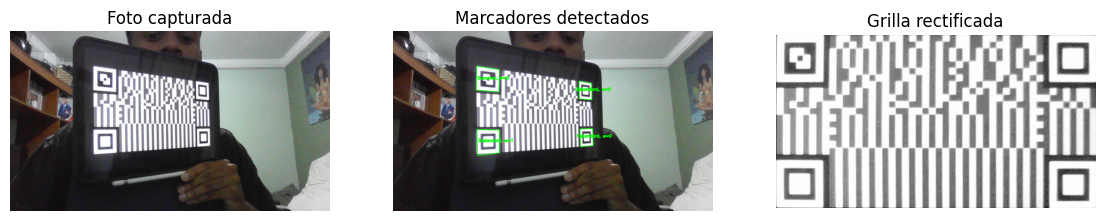

========== Diagnostico RX ==========
OK CRC: True
Convencion Manchester: 01->1
Pares Manchester invalidos: 0
Nivel bajo estimado: 128.0
Nivel alto estimado: 254.0
Errores de preambulo: 0
Frame index: 0
Total frames: 1
Payload bits: 104
CRC RX: 27943
CRC calculado: 27943
Correccion erasures usada: False
Erasures corregidos: 0
Texto decodificado:
F*to 4ngulosa
Decodificacion exitosa.
Texto decodificado:
F*to 4ngulosa


In [70]:
rx_result = rx.rx_from_camera_once(
    cfg,
    camera_index=0,
    width=1280,
    height=720,
    debug=True,
)

print("Texto decodificado:")
print(rx_result["text"])

Marcadores candidatos detectados: 4
  0: tipo=anchor, error=0, centro=(147.5, 131.5), area=27889.0
  1: tipo=standard, error=0, centro=(1131.5, 587.5), area=27889.0
  2: tipo=standard, error=0, centro=(147.5, 587.5), area=27889.0
  3: tipo=standard, error=0, centro=(1131.5, 131.5), area=27889.0


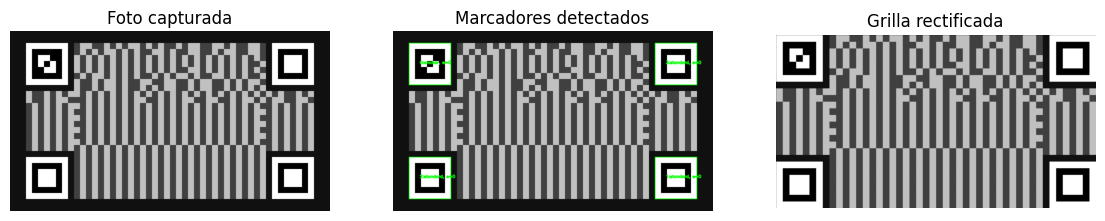

========== Diagnostico RX ==========
OK CRC: True
Convencion Manchester: 01->1
Pares Manchester invalidos: 0
Nivel bajo estimado: 64.0
Nivel alto estimado: 192.0
Errores de preambulo: 0
Frame index: 0
Total frames: 1
Payload bits: 64
CRC RX: 47829
CRC calculado: 47829
Correccion erasures usada: False
Erasures corregidos: 0
Texto decodificado:
Ñengoso
Ñengoso


In [55]:
rx_result = rx.rx_from_image_file(
    "outputs/fase1/frames/tx_frame_000.png",
    cfg,
    debug=True,
)

print(rx_result["text"])

# **FASE C: Integración en tiempo real (transmisión multi-cuadro)**

**Objetivo:** salir de la fotografía estática y transmitir una secuencia de cuadros en tiempo real para
enviar mensajes completos sobre el canal óptico real.

In [19]:
from modulo_1_fase_c_tx import (
    TxVisualConfig,
    encode_text_to_frames,
    save_frames,
    save_frames_as_video,
    transmit_fullscreen_opencv,
    print_transmission_summary,
)

cfg = TxVisualConfig(
    frame_duration_s=0.12,
)

## Ejecución: Creación del Mensaje + Sincronización Visual

In [20]:
text = "bloque 1 * bloque 2 * bloque 3 * bloque 4 * bloque 5 * bloque 6 * bloque 7 * bloque 8 * bloque 9 * bloque 10 * bloque 11 * bloque 12 * bloque 13 * bloque 14 * bloque 15 * bloque 16 * bloque 17 * bloque 18 * bloque 19 * bloque 20 * bloque 21 * bloque 22 * bloque 23 * bloque 24 * bloque 25 * bloque 26 * bloque 27 * bloque 28 * bloque 29 * bloque 30 * bloque 31 * bloque 32 * bloque 33 * bloque 34 * bloque 35 * bloque 36 * bloque 37 * bloque 38 * bloque 39 * bloque 40 * bloque 41 * bloque 42 * bloqu"
#text = "Este es un mensaje de prueba para la transmisión visual. Debería ser decodificado correctamente por el receptor. El mensaje se divide en varios frames, cada uno con su propio preámbulo, índice y CRC. La grilla visual tiene marcadores fiduciales para ayudar a la sincronización y corrección de perspectiva. Este sistema utiliza BPSK en escala de grises con codificación Manchester para representar los bits de datos. La duración por frame es de 120 ms, lo que permite una transmisión relativamente rápida pero aún legible por la cámara. Al finalizar la transmisión, se guardarán los frames como imágenes PNG y también se compilarán en un video MP4 para facilitar su revisión."  # Puedes ajustar el texto para probar diferentes longitudes y caracteres.

print_transmission_summary(text, cfg)

frames = encode_text_to_frames(text, cfg)

save_frames(frames, cfg)

save_frames_as_video(
    frames,
    cfg,
    output_path="outputs/fase_c/tx_sequence.mp4",
    video_fps=30,
    codec="mp4v",
)

# Para transmisión real desde la pantalla:
transmit_fullscreen_opencv(frames, cfg, fullscreen=True, loop=True)

=== TX Fase C: resumen ===
Texto: 500 caracteres
Bytes UTF-8: 500
Frames SYNC: 3
Frames DATA: 13
Frames END: 3
Frames visuales totales: 19
Duración por frame: 0.120 s
Tiempo estimado TX: 2.28 s
Payload útil por DATA: 312 bits = 39.0 bytes
CRC16 mensaje: 0xC098
Frames guardados en: C:\Users\Dell\Documents\de la U\2026-1\COMUNICACIONES DIGITALES\Proyecto Final\outputs\fase_c\frames
Video guardado en: C:\Users\Dell\Documents\de la U\2026-1\COMUNICACIONES DIGITALES\Proyecto Final\outputs\fase_c\tx_sequence.mp4 | fps=30, repeat_each=4, duración≈2.53 s


## Ejecución: Captura Continua y Decodificación

In [5]:
import importlib
import modulo_1_fase_c_tx as tx
import rx_camera_module_fase_c as rx

importlib.reload(tx)
importlib.reload(rx)

<module 'rx_camera_module_fase_c' from 'c:\\Users\\Dell\\Documents\\de la U\\2026-1\\COMUNICACIONES DIGITALES\\Proyecto Final\\rx_camera_module_fase_c.py'>

In [14]:
cfg = tx.TxVisualConfig(
    frame_duration_s=0.12,
)

rx.bind_tx_module(tx)

result = rx.rx_from_camera_continuous(
    cfg,
    camera_index=1,
    width=1280,
    height=720,
    max_seconds=120,
    require_sync=True,
    require_end=True,
    process_every_n=1,
    final_erasures=0,
    show_preview=True,
    preview_scale=1.0,
    debug=True,
)

print(result["ok"])
print(result["text"])

Recepcion Fase C incompleta o CRC global fallido.
DATA recibidos: 0/None
Faltantes: []
SYNC vistos: 0 | END vistos: 0
False



## Optimizado (Menos Lag por el alto coste de procesamiento)

In [5]:
cfg = tx.TxVisualConfig(
    frame_duration_s=0.12,
)

rx.bind_tx_module(tx)

result = rx.rx_from_camera_continuous(
    cfg,
    camera_index=0,
    width=640,
    height=480,
    max_seconds=120,
    require_sync=True,
    require_end=True,
    process_every_n=1,
    final_erasures=2,
    show_preview=True,
    preview_scale=0.5,
    debug=False,
)

print(result["ok"])
print(result["text"])

Recepcion Fase C incompleta o CRC global fallido.
DATA recibidos: 0/None
Faltantes: []
SYNC vistos: 0 | END vistos: 0
False



## Captura de Video (sin Decodificación)

In [18]:
import video_recorder_module as vr

info = vr.record_video_on_key(
    duration_s=10,
    camera_index=0,
    width=1280,
    height=720,
    output_dir="outputs/fase_c/raw_recordings",
    fps=30,
)

print(info)

{'ok': True, 'cancelled': False, 'recording_started': True, 'output_path': 'C:\\Users\\Dell\\Documents\\de la U\\2026-1\\COMUNICACIONES DIGITALES\\Proyecto Final\\outputs\\fase_c\\raw_recordings\\raw_camera_recording_20260526_214440.mp4', 'frames_recorded': 300, 'duration_s_requested': 10.0, 'duration_s_actual': 10.022139299893752, 'effective_fps': 29.93372882007142, 'codec': 'mp4v', 'fps_writer': 30.0, 'camera_index': 0, 'message': 'Video guardado correctamente.'}


## Decodificación a partir de un video

In [20]:
result = rx.rx_from_video_file(
    "outputs/fase_c/raw_recordings/raw_camera_recording_20260526_213630.mp4",
    cfg,
    require_sync=True,
    require_end=True,
    debug=True,
)

print("\n")
print("Texto decodificado:")
print(result["text"])

frame_video=1 SYNC seq=1 -> sync
frame_video=2 SYNC seq=1 -> sync
frame_video=3 SYNC seq=1 -> sync
frame_video=4 SYNC seq=1 -> sync
frame_video=5 SYNC seq=1 -> sync
frame_video=6 SYNC seq=2 -> sync
frame_video=7 SYNC seq=2 -> sync
frame_video=8 SYNC seq=2 -> sync
frame_video=9 SYNC seq=2 -> sync
frame_video=10 DATA seq=0 -> new_data
frame_video=11 DATA seq=0 -> duplicate_ignored
frame_video=12 DATA seq=0 -> duplicate_ignored
frame_video=13 DATA seq=1 -> new_data
frame_video=14 DATA seq=1 -> duplicate_ignored
frame_video=15 DATA seq=1 -> duplicate_ignored
frame_video=16 DATA seq=1 -> duplicate_ignored
frame_video=17 DATA seq=1 -> duplicate_ignored
frame_video=18 DATA seq=2 -> new_data
frame_video=19 DATA seq=2 -> duplicate_replaced
frame_video=20 DATA seq=2 -> duplicate_ignored
frame_video=21 DATA seq=2 -> duplicate_ignored
frame_video=22 DATA seq=3 -> new_data
frame_video=23 DATA seq=3 -> duplicate_ignored
frame_video=24 DATA seq=3 -> duplicate_ignored
frame_video=25 DATA seq=4 -> new_

# **FASE C: Modulación MultiNivel (4-ASK)**

## Ejecución: Creación del Mensaje + Sincronización Visual

In [27]:
from modulo_1_fase_c_tx_4ask import (
    cfg,
    print_capacity,
    print_transmission_summary,
    encode_text_to_frames,
    transmit_fullscreen_opencv,
    save_frames,
    save_frames_as_video,
)

#text = "Hola, esta es una prueba con modulación 4-ASK."
text = "bloque 1 * bloque 2 * bloque 3 * bloque 4 * bloque 5 * bloque 6 * bloque 7 * bloque 8 * bloque 9 * bloque 10 * bloque 11 * bloque 12 * bloque 13 * bloque 14 * bloque 15 * bloque 16 * bloque 17 * bloque 18 * bloque 19 * bloque 20 * bloque 21 * bloque 22 * bloque 23 * bloque 24 * bloque 25 * bloque 26 * bloque 27 * bloque 28 * bloque 29 * bloque 30 * bloque 31 * bloque 32 * bloque 33 * bloque 34 * bloque 35 * bloque 36 * bloque 37 * bloque 38 * bloque 39 * bloque 40 * bloque 41 * bloque 42 * bloqu"


print_capacity(cfg)
print_transmission_summary(text, cfg)

frames = encode_text_to_frames(text, cfg)

# Vista rápida dentro del notebook
# show_frame_inline(frames[0])

# Transmisión en pantalla completa
transmit_fullscreen_opencv(frames, cfg, fullscreen=True, loop=True)

Modulación: 4-ASK grayscale Gray-coded
GRAY_LEVELS: [50, 110, 170, 230]
Capacidad DATA: 912 símbolos 4-ASK/frame
Capacidad cruda: 1824 bits/frame antes de 4-ASK
Overhead Fase C: 144 bits/frame
Payload útil DATA: 1680 bits/frame = 210.0 bytes/frame
=== TX Fase C 4-ASK: resumen ===
Modulación: 4-ASK grayscale Gray-coded
GRAY_LEVELS: [50, 110, 170, 230]
Texto: 500 caracteres
Bytes UTF-8: 500
Frames SYNC: 3
Frames DATA: 3
Frames END: 3
Frames visuales totales: 9
Duración por frame: 0.120 s
Tiempo estimado TX: 1.08 s
Símbolos DATA/frame: 912
Payload útil por DATA: 1680 bits = 210.0 bytes
CRC16 mensaje: 0xC098


## Captura de Video (sin Decodificación)

In [4]:
import video_recorder_module as vr

info = vr.record_video_on_key(
    duration_s=10,
    camera_index=0,
    width=1280,
    height=720,
    output_dir="outputs/fase_c/raw_recordings",
    fps=30,
)

print(info)

{'ok': True, 'cancelled': False, 'recording_started': True, 'output_path': 'C:\\Users\\Dell\\Documents\\de la U\\2026-1\\COMUNICACIONES DIGITALES\\Proyecto Final\\outputs\\fase_c\\raw_recordings\\raw_camera_recording_20260528_130103.mp4', 'frames_recorded': 301, 'duration_s_requested': 10.0, 'duration_s_actual': 10.042240499999025, 'effective_fps': 29.973390898179467, 'codec': 'mp4v', 'fps_writer': 30.0, 'camera_index': 0, 'message': 'Video guardado correctamente.'}


## Decodificación a partir de un video

In [ ]:
import importlib
import modulo_1_fase_c_tx_4ask as tx4
import rx_video_module_fase_c_4ask as rx4

importlib.reload(tx4)
importlib.reload(rx4)

cfg = tx4.TxVisualConfig(frame_duration_s=0.12)
rx4.bind_tx_module(tx4)

result = rx4.rx_from_video_file(
    "outputs/fase_c/raw_recordings/document_4954331676009301890.mp4",
    cfg,
    require_sync=True,
    require_end=True,
    process_every_n=1,
    debug=True,
)

print("\n")
print(result["ok"])
print(result["text"])

frame_video=00001 t=  0.000s END seq=3 -> waiting_sync DATA=0/? conf=0.933
frame_video=00002 t=  0.033s END seq=3 -> waiting_sync DATA=0/? conf=0.930
frame_video=00003 t=  0.067s SYNC seq=0 -> sync DATA=0/1 conf=0.928
frame_video=00004 t=  0.100s SYNC seq=0 -> sync DATA=0/1 conf=0.935
frame_video=00005 t=  0.133s SYNC seq=0 -> sync DATA=0/1 conf=0.934
frame_video=00006 t=  0.167s SYNC seq=0 -> sync DATA=0/1 conf=0.938
frame_video=00007 t=  0.200s SYNC seq=1 -> sync DATA=0/1 conf=0.937
frame_video=00008 t=  0.233s SYNC seq=1 -> sync DATA=0/1 conf=0.934
frame_video=00009 t=  0.267s SYNC seq=1 -> sync DATA=0/1 conf=0.936
frame_video=00010 t=  0.300s SYNC seq=1 -> sync DATA=0/1 conf=0.937
frame_video=00011 t=  0.333s SYNC seq=2 -> sync DATA=0/1 conf=0.932
frame_video=00012 t=  0.367s SYNC seq=2 -> sync DATA=0/1 conf=0.936
frame_video=00013 t=  0.400s SYNC seq=2 -> sync DATA=0/1 conf=0.933
frame_video=00014 t=  0.433s SYNC seq=2 -> sync DATA=0/1 conf=0.937
frame_video=00016 t=  0.500s DATA 

# **FASE C: Modulación MultiNivel (8-CSK)**

| Símbolo | Bits Gray |        RGB        |  Muestra      |
| ------: | :-------: | :---------------: |:-------------:|
|       0 |   `000`   | `(217, 134, 159)` |<p style="background-color:rgb(217, 134, 159)">*</p>|
|       1 |   `001`   | `(213, 140, 115)` |<p style="background-color:rgb(213, 140, 115)">*</p>|       
|       2 |   `011`   |  `(179, 156, 95)` |<p style="background-color:rgb(179, 156, 95)">*</p>|        
|       3 |   `010`   | `(128, 169, 112)` |<p style="background-color:rgb(128, 169, 112)">*</p>|       
|       4 |   `110`   |  `(67, 175, 157)` |<p style="background-color:rgb(67, 175, 157)">*</p>|      
|       5 |   `111`   |  `(30, 172, 202)` |<p style="background-color:rgb(30, 172, 202)">*</p>|     
|       6 |   `101`   | `(113, 161, 220)` |<p style="background-color:rgb(113, 161, 220)">*</p>|     
|       7 |   `100`   | `(182, 144, 203)` |<p style="background-color:rgb(182, 144, 203)">*</p>|    

## Ejecución: Creación del Mensaje + Sincronización Visual

In [3]:
from modulo_1_fase_c_tx_8csk import (
    TxVisualConfig,
    encode_text_to_frames,
    print_capacity,
    print_csk_constellation,
    print_transmission_summary,
    save_frames,
    save_frames_as_video,
    transmit_fullscreen_opencv,
)

cfg = TxVisualConfig(
    frame_duration_s=0.12,
    debug_text=True,
)

#mensaje = "Este es un mensaje de prueba transmitido mediante modulación 8-CSK con pilotos RGB y etiquetado Gray."

mensaje = "bloque 1 * bloque 2 * bloque 3 * bloque 4 * bloque 5 * bloque 6 * bloque 7 * bloque 8 * bloque 9 * bloque 10 * bloque 11 * bloque 12 * bloque 13 * bloque 14 * bloque 15 * bloque 16 * bloque 17 * bloque 18 * bloque 19 * bloque 20 * bloque 21 * bloque 22 * bloque 23 * bloque 24 * bloque 25 * bloque 26 * bloque 27 * bloque 28 * bloque 29 * bloque 30 * bloque 31 * bloque 32 * bloque 33 * bloque 34 * bloque 35 * bloque 36 * bloque 37 * bloque 38 * bloque 39 * bloque 40 * bloque 41 * bloque 42 * bloqu"


print_csk_constellation(cfg)
print_capacity(cfg)
print_transmission_summary(mensaje, cfg)

frames = encode_text_to_frames(mensaje, cfg)

transmit_fullscreen_opencv(
    frames,
    cfg,
    fullscreen=True,
    loop=True,
)

=== Constelación 8-CSK ===
Símbolo | bits | RGB             | Y' aprox.
      0 | 000  | (217, 134, 159) |   153.45
      1 | 001  | (213, 140, 115) |   153.71
      2 | 011  | (179, 156, 95)  |   156.49
      3 | 010  | (128, 169, 112) |   156.17
      4 | 110  | (67, 175, 157)  |   150.74
      5 | 111  | (30, 172, 202)  |   143.98
      6 | 101  | (113, 161, 220) |   155.06
      7 | 100  | (182, 144, 203) |   156.34
=== Capacidad visual 8-CSK ===
Celdas DATA: 912 símbolos/frame
Bits por símbolo: 3
Capacidad cruda: 2736 bits/frame
Pilotos RGB: 80 celdas/frame
Referencias distintas: 11
Overhead Fase C: 144 bits/frame
Payload útil DATA: 2592 bits/frame = 324.0 bytes/frame
=== TX Fase C 8-CSK: resumen ===
Modulación: 8-CSK Gray
Versión de protocolo: 2
Texto: 500 caracteres
Bytes UTF-8: 500
Bits por símbolo: 3
Celdas DATA por frame: 912
Pilotos RGB por frame: 80
Frames SYNC: 3
Frames DATA: 2
Frames END: 3
Frames visuales totales: 8
Duración por frame: 0.120 s
Tiempo estimado TX: 0.96 s


## Captura de Video (sin Decodificación)

In [22]:
import video_recorder_module as vr

info = vr.record_video_on_key(
    duration_s=10,
    camera_index=0,
    width=1280,
    height=720,
    output_dir="outputs/fase_c/raw_recordings",
    fps=30,
)

print(info)

{'ok': False, 'cancelled': True, 'recording_started': False, 'output_path': None, 'frames_recorded': 0, 'duration_s_requested': 10.0, 'duration_s_actual': 0.0, 'effective_fps': 0.0, 'message': 'Grabacion cancelada antes de iniciar.'}


## Decodificación a partir de un video

In [23]:
import importlib

import modulo_1_fase_c_tx_8csk as tx
import rx_video_module_fase_c_8csk as rx

importlib.reload(tx)
importlib.reload(rx)

cfg = tx.TxVisualConfig(
    frame_duration_s=0.12,
)

rx.bind_tx_module(tx)

In [ ]:
result = rx.rx_from_video_file(
    path="outputs/fase_c/raw_recordings/111.mp4",
    cfg=cfg,
    require_sync=True,
    require_end=True,
    process_every_n=1,
    reuse_homography=False,
    debug=True,
)

print(result["text"])